# **Análisis de datos**
## TRABAJO FINAL - GRUPO 12
### INTEGRANTES:
* Gonzalo Martin Rodriguez
* Juan Pablo Castellino
* Nicolas Collazo
* Nicolas Ezequiel Lastra
  
### TEMA: "Airbnb Buenos aires"

Pagina de origen del dataset : https://insideairbnb.com/get-the-data/ --> Buenos Aires --> 	listings.csv.gz (sin filtrar)

#### **INSIDE AIRBNB** : Es un proyecto impulsado con la misión de proporcionar datos y defensa sobre el impacto de Airbnb en las comunidades residenciales.Trabaja hacia una visión en la que las comunidades estén empoderadas con datos e información para comprender, decidir y controlar el papel del alquiler de viviendas residenciales a turistas.

#### **Premisa**: Gonzalo recibio una herencia importante y quiere invertir el dinero en algo que genere capital de manera sostenida para no tener que trabajar mas. Una de las recomendaciones que recibio, ya que vive en Buenos Aires, es iniciar una carrera como **"empresario Airbnb"**. Lo cual suena bien, pero la decision de si es un buen negocio y de que forma encararlo (que propiedades comprar, que tipo, ubicacion, etc) parece dificil. Con el objetivo de tomar una decision, trabajaremos con el dataset de Inside Airbnb de Buenos Aires para tratar de encontrar un modelo que aumente las chances de convertirse en un empresario Airbnb **exitoso** (aun no sabemos lo que significa en terminos del dataset).

In [20]:
import pandas as pd
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr
from IPython.display import display, HTML


In [21]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.legend(loc="best")
    ax.axis('equal') # Asegura que el gráfico sea circular

In [22]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

In [23]:
#Generamos el dataset a partir del archivo csv descargado

df = pd.read_csv("listings_ext.csv") #Dataset principal
df_comunas = pd.read_csv("barrios_comunas_caba.csv") #Dataset principal
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,...,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,...,3.00,5.00,4.00,NaN,NaN,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,...,4.73,4.59,4.45,NaN,NaN,39,34,4,0,0.80
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,NaN,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,...,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN


In [24]:
#Observamos tamaño de dataset

print(f'El dataset tiene: \033[1m"{df.shape[0]}"\033[0m filas y columnas: \033[1m"{df.shape[1]}"\033[0m')

El dataset tiene: "27348" filas y columnas: "85"


In [25]:
#Visualizamos de forma general el dataset, que cantidad de valores nulos o faltantes posee y que tipo de variable.
df = df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  Int64  
 1   listing_url                                   27348 non-null  string 
 2   scrape_id                                     27348 non-null  Int64  
 3   last_scraped                                  27348 non-null  string 
 4   source                                        27348 non-null  string 
 5   name                                          27348 non-null  string 
 6   description                                   26752 non-null  string 
 7   neighborhood_overview                         0 non-null      Int64  
 8   picture_url                                   27347 non-null  string 
 9   host_id                                       27348 non-null 

### EXPLORACION DE VARIABLES
* 52 variables numericas
* 33 variables categoricas


| Nombre de la variable | Descripción | Tipo de variable | Observaciones |
| :--- | :--- | :--- | :--- |
| id | Identificador único de Airbnb para el anuncio. | Categórica Nominal | 27348 muestras |
| listing_url | Enlace URL del anuncio de Airbnb. | Categórica Nominal | 27348 muestras |
| scrape_id | Identificador del proceso de raspado de datos de Inside Airbnb. | Categórica Nominal | 27348 muestras |
| last_scraped | Fecha en la que se recopilaron los datos de este anuncio. | Categórica Ordinal | 27348 muestras |
| source | Origen de los datos del anuncio. | Categórica Nominal | 27348 muestras |
| name | Nombre o título comercial del anuncio. | Categórica Nominal | 27348 muestras |
| description | Descripción textual detallada del espacio ofrecido. | Categórica Nominal | 26752 muestras |
| neighborhood_overview | Descripción del barrio proporcionada por el anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| picture_url | URL de la foto principal del alojamiento. | Categórica Nominal | 27347 muestras |
| host_id | Identificador único de Airbnb para el anfitrión. | Categórica Nominal | 27348 muestras |
| host_url | Enlace URL del perfil del anfitrión. | Categórica Nominal | 27348 muestras |
| host_profile_id | Identificador interno del perfil del anfitrión. | Categórica Nominal | 27348 muestras |
| host_profile_url | Enlace URL específico del perfil completo del anfitrión. | Categórica Nominal | 27348 muestras |
| host_name | Nombre del anfitrión. | Categórica Nominal | 27348 muestras |
| host_since | Fecha en la que el anfitrión creó su cuenta en Airbnb. | Categórica Ordinal | **0 muestras (Sin datos)** |
| hosts_time_as_user_years | Tiempo total del anfitrión registrado como usuario en años. | Numérica Discreta | 27348 muestras |
| hosts_time_as_user_months | Tiempo total del anfitrión registrado como usuario en meses. | Numérica Discreta | 27348 muestras |
| hosts_time_as_host_years | Tiempo total del usuario operando como anfitrión en años. | Numérica Discreta | 27348 muestras |
| hosts_time_as_host_months | Tiempo total del usuario operando como anfitrión en meses. | Numérica Discreta | 27348 muestras |
| host_location | Ubicación geográfica declarada por el anfitrión. | Categórica Nominal | 21565 muestras |
| host_about | Biografía o texto de presentación del anfitrión. | Categórica Nominal | 15564 muestras |
| host_response_time | Tiempo promedio que tarda el anfitrión en responder mensajes. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_response_rate | Tasa o porcentaje de mensajes respondidos por el anfitrión. | Numérica Continua | **0 muestras (Sin datos)** |
| host_acceptance_rate | Tasa o porcentaje de solicitudes de reserva aceptadas. | Numérica Continua | **0 muestras (Sin datos)** |
| host_is_superhost | Indicador de si el anfitrión posee el estatus de Superhost. | Categórica Nominal | 27348 muestras |
| host_thumbnail_url | URL de la foto de perfil en miniatura del anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_picture_url | URL de la foto de perfil en tamaño completo del anfitrión. | Categórica Nominal | 27348 muestras |
| host_neighbourhood | Barrio del anfitrión según su propia declaración. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_listings_count | Número de anuncios que tiene el anfitrión en la plataforma. | Numérica Discreta | 27348 muestras |
| host_total_listings_count | Número total de anuncios del anfitrión (conteo alternativo). | Numérica Discreta | **0 muestras (Sin datos)** |
| host_verifications | Métodos de verificación completados por el anfitrión. | Categórica Nominal | **0 muestras (Sin datos)** |
| host_has_profile_pic | Indicador de si el anfitrión tiene una foto de perfil. | Categórica Nominal | 27348 muestras |
| host_identity_verified | Indicador de si la identidad del anfitrión está verificada. | Categórica Nominal | 27348 muestras |
| neighbourhood | Barrio general donde se ubica el alojamiento. | Categórica Nominal | **0 muestras (Sin datos)** |
| neighbourhood_cleansed | Barrio normalizado y estandarizado mediante geoprocesamiento. | Categórica Nominal | 27348 muestras |
| neighbourhood_group_cleansed | Distrito o comuna mayor de barrios normalizados. | Categórica Nominal | **0 muestras (Sin datos)** |
| latitude | Coordenada de latitud del alojamiento (proyección WGS84). | Numérica Continua | 27348 muestras |
| longitude | Coordenada de longitud del alojamiento (proyección WGS84). | Numérica Continua | 27348 muestras |
| property_type | Tipo de propiedad detallado (ej. Habitación en departamento). | Categórica Nominal | 27348 muestras |
| room_type | Tipo de habitación (Apto entero, Habitación privada/compartida). | Categórica Nominal | 27348 muestras |
| accommodates | Capacidad máxima de huéspedes que puede alojar el lugar. | Numérica Discreta | 27348 muestras |
| bathrooms | Número total de baños disponibles en el alojamiento. | Numérica Discreta | 27340 muestras |
| bathrooms_text | Descripción textual de la cantidad y tipo de baños. | Categórica Nominal | 27337 muestras |
| bedrooms | Número de dormitorios disponibles. | Numérica Discreta | 27288 muestras |
| beds | Número de camas disponibles en el alojamiento. | Numérica Discreta | 27340 muestras |
| amenities | Lista de servicios y comodidades ofrecidas en formato JSON. | Categórica Nominal | 27348 muestras |
| price | Precio por noche de la estadía. | Numérica Continua | **0 muestras (Sin datos)** |
| minimum_nights | Cantidad mínima de noches requeridas para reservar. | Numérica Discreta | 27242 muestras |
| maximum_nights | Cantidad máxima de noches permitidas para una reserva. | Numérica Discreta | 27242 muestras |
| minimum_minimum_nights | Valor mínimo de las noches mínimas del calendario. | Numérica Discreta | 27242 muestras |
| maximum_minimum_nights | Valor máximo de las noches mínimas del calendario. | Numérica Discreta | 27242 muestras |
| minimum_maximum_nights | Valor mínimo de las noches máximas del calendario. | Numérica Discreta | 27242 muestras |
| maximum_maximum_nights | Valor máximo de las noches máximas del calendario. | Numérica Discreta | 27242 muestras |
| minimum_nights_avg_ntm | Promedio ponderado del requisito de noches mínimas. | Numérica Continua | 27348 muestras |
| maximum_nights_avg_ntm | Promedio ponderado del requisito de noches máximas. | Numérica Continua | 27348 muestras |
| calendar_updated | Fecha o indicador de la última actualización del calendario. | Categórica Ordinal | **0 muestras (Sin datos)** |
| has_availability | Indicador de si el anuncio tiene disponibilidad actual. | Categórica Nominal | 27144 muestras |
| availability_30 | Días disponibles para reservar en los próximos 30 días. | Numérica Discreta | 27348 muestras |
| availability_60 | Días disponibles para reservar en los próximos 60 días. | Numérica Discreta | 27348 muestras |
| availability_90 | Días disponibles para reservar en los próximos 90 días. | Numérica Discreta | 27348 muestras |
| availability_365 | Días disponibles para reservar en los próximos 365 días. | Numérica Discreta | 27348 muestras |
| calendar_last_scraped | Última fecha en que se revisó el calendario de este anuncio. | Categórica Ordinal | 27348 muestras |
| number_of_reviews | Número total de reseñas históricas recibidas. | Numérica Discreta | 27348 muestras |
| number_of_reviews_ltm | Número de reseñas recibidas en los últimos 12 meses. | Numérica Discreta | 27348 muestras |
| number_of_reviews_l30d | Número de reseñas recibidas en los últimos 30 días. | Numérica Discreta | 27348 muestras |
| availability_eoy | Disponibilidad proyectada hacia el final del año en curso. | Numérica Discreta | 27348 muestras |
| number_of_reviews_ly | Número de reseñas recibidas durante el año pasado. | Numérica Discreta | 27348 muestras |
| estimated_occupancy_l365d | Ocupación estimada del alojamiento en los últimos 365 días. | Numérica Discreta | 27348 muestras |
| estimated_revenue_l365d | Ingresos estimados generados en los últimos 365 días. | Numérica Continua | **0 muestras (Sin datos)** |
| first_review | Fecha de la primera reseña registrada en el anuncio. | Categórica Ordinal | 24045 muestras |
| last_review | Fecha de la última reseña registrada en el anuncio. | Categórica Ordinal | 24045 muestras |
| review_scores_rating | Calificación promedio general otorgada por los huéspedes. | Numérica Continua | 24045 muestras |
| review_scores_accuracy | Calificación promedio sobre la veracidad del anuncio. | Numérica Continua | 24044 muestras |
| review_scores_cleanliness | Calificación promedio sobre la limpieza del alojamiento. | Numérica Continua | 24045 muestras |
| review_scores_checkin | Calificación promedio sobre el proceso de llegada. | Numérica Continua | 24045 muestras |
| review_scores_communication | Calificación promedio sobre la comunicación con el anfitrión. | Numérica Continua | 24045 muestras |
| review_scores_location | Calificación promedio sobre la ubicación del alojamiento. | Numérica Continua | 24045 muestras |
| review_scores_value | Calificación promedio sobre la relación calidad-precio. | Numérica Continua | 24045 muestras |
| license | Número de licencia turística o registro gubernamental. | Categórica Nominal | 461 muestras |
| instant_bookable | Indicador de si permite reserva instantánea automática. | Categórica Nominal | **0 muestras (Sin datos)** |
| calculated_host_listings_count | Conteo total calculado de anuncios activos del anfitrión. | Numérica Discreta | 27348 muestras |
| calculated_host_listings_count_entire_homes | Número calculado de propiedades enteras del anfitrión. | Numérica Discreta | 27348 muestras |
| calculated_host_listings_count_private_rooms | Número calculado de habitaciones privadas del anfitrión. | Numérica Discreta | 27348 muestras |


### Data wrangling (columnas vacias)

#### Como se puede observar existen 15 features completamente vacias, por lo cual se eliminan ya que no existe algun analisis a realizar de algo totalmente faltante. Las variables a eliminar son:

* neighborhood_overview
* host_since
* host_response_time
* host_response_rate
* host_acceptance_rate
* host_thumbnail_url
* host_neighbourhood
* host_total_listings_count
* host_verifications
* neighbourhood
* neighbourhood_group_cleansed
* price
* calendar_updated
* estimated_revenue_l365d
* instant_bookable

In [26]:
df_1 = df.drop(columns=["neighborhood_overview", "host_since", "host_response_time", "host_response_rate", "host_acceptance_rate", "host_thumbnail_url", "host_neighbourhood", "host_total_listings_count", "host_verifications", "neighbourhood", "neighbourhood_group_cleansed", "price", "calendar_updated", "estimated_revenue_l365d", "instant_bookable"], errors='ignore').copy()

df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 70 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  Int64  
 1   listing_url                                   27348 non-null  string 
 2   scrape_id                                     27348 non-null  Int64  
 3   last_scraped                                  27348 non-null  string 
 4   source                                        27348 non-null  string 
 5   name                                          27348 non-null  string 
 6   description                                   26752 non-null  string 
 7   picture_url                                   27347 non-null  string 
 8   host_id                                       27348 non-null  Int64  
 9   host_url                                      27348 non-null 

### Data cleaning (Conversion de variables por formato incorrecto, y definicion unicada de categoricas binarias)

#### Para evitar confuciones durante el tratamiento se cambia el tipo de variable tomado en logica para que coincida con el definido por su significado.

**Variables que deben convertirse a bool**
* host_is_superhost
* host_has_profile_pic
* host_identity_verified
* has_availability

**Variables que deben convertirse a string**
* id 
* scrape_id 
* host_id 
* host_profile_id


**Variables que deben convertirse a fecha**
* last_scraped
* calendar_last_scraped
* first_review
* last_review

In [27]:
# Conversión a Booleanos tolerantes a nulos
df_2 = df_1.copy()
mapeo = {"t": True, "f": False, "true": True, "false": False}
cols_bool = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
for col in cols_bool:
    df_2[col] = df_2[col].astype(str).str.lower().str.strip().map(mapeo).astype("boolean")

# Conversión a Fechas
cols_fecha = ["last_scraped", "calendar_last_scraped", "first_review", "last_review"]
for col in cols_fecha:
    df_2[col] = pd.to_datetime(df_2[col], errors="coerce")

# Conversión de IDs a Texto
cols_id = ["id", "scrape_id", "host_id", "host_profile_id"]
for col in cols_id:
    df_2[col] = df_2[col].astype("string")

df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 70 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  string        
 1   listing_url                                   27348 non-null  string        
 2   scrape_id                                     27348 non-null  string        
 3   last_scraped                                  27348 non-null  datetime64[ns]
 4   source                                        27348 non-null  string        
 5   name                                          27348 non-null  string        
 6   description                                   26752 non-null  string        
 7   picture_url                                   27347 non-null  string        
 8   host_id                                       27348 non-null  stri

### Data wrangling (Datos no explicitos)

Los amenities son un atributo muy interesante a investigar ya que puede llegar a mostrar algun patron que siga la gente al buscar alojamiento y ayude a los anfitriones a la hora de tomar la decision de comprar o al menos de como equiparla para ser mas atractiva. Sin embargo, ese atributo tiene demasiadas palabras, es decir, no se encuentra de forma limpia, filtrado dentro del dataset. Por eso, vamos a encontrar el top 10 de palabras mas frecuentes y considerar si vale la pena crear nuevos atributos con ellas concatenamos todo el texto en una sola linea, lo vamos a pasamos a minuscula, vamos a contar la frecuencia de palabras, imprimimos, filtramos palabras que no son de utilidad y repetimos el proceso sin las palabras filtradas hasta que el top 10 son palabras utiles.


In [29]:
# Combinamos toda la columna amenities en un solo string para procesarlo.
columna_amenities_string = " ".join(df_2["amenities"].astype(str))

# Convertimos a minuscula todo el texto y extrae solamente palabras.
columna_amenities_palabras = re.findall(r"\b\w+\b", columna_amenities_string.lower())
palabras_a_borrar = ['and', 'allowed', 'water', 'hot', 'clothing', 'in', 'dishes', 'silverware', 'heating', 'basics', 'refrigerator', 'cooking', 'dining', 'hangers', 'maker', 'bed']
columna_amenities_palabras = [w for w in columna_amenities_palabras if w not in palabras_a_borrar]

# Cuenta la frecuencia de cada palabra
columna_amenities_palabras_frecuencia = Counter(columna_amenities_palabras)

# Imprimimos el top 10 con mayor frecuencia
amenities_top_10_words = columna_amenities_palabras_frecuencia.most_common(10)

print(amenities_top_10_words)

[('coffee', 28636), ('wifi', 28026), ('kitchen', 26058), ('dryer', 24364), ('parking', 23796), ('tv', 20178), ('linens', 19906), ('paid', 18968), ('air', 18716), ('conditioning', 18711)]


In [30]:
df_3 = df_2.copy()

#Combinamos toda la columna amenities en un solo string
columna_amenities_string = " ".join(df_3["amenities"].astype(str))

#Convertimos a minúsculas para estandarizar
texto_minusculas = columna_amenities_string.lower()

# Unificamos "air conditioning" (o variantes con espacios) en una sola palabra
texto_unificado = texto_minusculas.replace("air conditioning", "air_conditioning")

#Extraemos solamente las palabras
columna_amenities_palabras = re.findall(r"\b\w+\b", texto_unificado)

#Agregamos "air" y "conditioning" individuales a la lista de borrado para ignorarlas por separado
palabras_a_borrar = [
    "and",
    "allowed",
    "water",
    "hot",
    "clothing",
    "in",
    "dishes",
    "silverware",
    "heating",
    "basics",
    "refrigerator",
    "cooking",
    "dining",
    "hangers",
    "maker",
    "bed",
    "air",
    "conditioning",
]

columna_amenities_palabras = [
    w for w in columna_amenities_palabras if w not in palabras_a_borrar
]

#Cuenta la frecuencia de cada palabra usando la lista filtrada correcta
columna_amenities_palabras_frecuencia = Counter(columna_amenities_palabras)

#Obtenemos e imprimimos el top 10 con la frecuencia conjunta
amenities_top_10_words = columna_amenities_palabras_frecuencia.most_common(10)

#Creamos un dataframe con 2 columnas con la palabra y su frecuencia.
df_amenities_top_10_words = pd.DataFrame(amenities_top_10_words, columns=['palabra', 'frecuencia'])

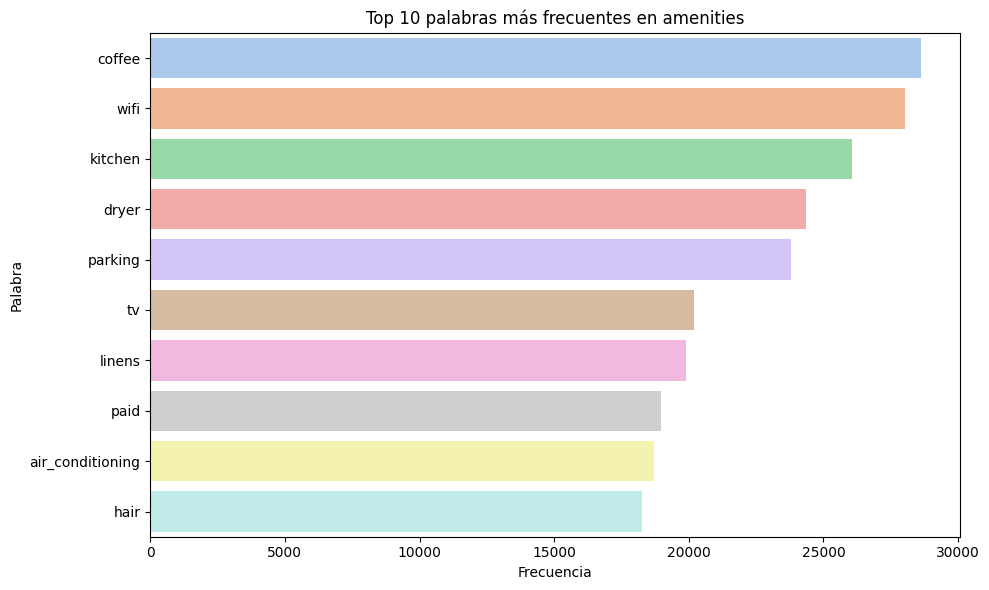

In [31]:
#Creamos un grafico con las palabras y su frecuencia.
plt.figure(figsize=(10, 6))
sns.barplot(data=df_amenities_top_10_words, x='frecuencia', y='palabra', 
            hue='palabra', legend=False, palette='pastel')
plt.title('Top 10 palabras más frecuentes en amenities')
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')
plt.tight_layout()
plt.show()

In [32]:
#Agremamos como columnas (features) las 10 palabras mas frecuentes, agregandose como categoricas nominales (binarias) y eliminando la columna amenities la cual sera redundante.

lista_top_10_servicios = df_amenities_top_10_words["palabra"].tolist()

#Creamos cada palabra del top 10 como columna y verificamos cada muestra si tiene o no dicha caracteristica.
for servicio in lista_top_10_servicios:
    # Si la palabra tiene guion bajo (como air_conditioning), lo cambia por un espacio para buscarlo en el texto original
    termino_busqueda = servicio.replace("_", " ")

    df_3[servicio] = (
        df_3["amenities"]
        .str.contains(termino_busqueda, case=False, na=False)
        .astype("boolean")
    )

#Descartamos la columna amenities
df_3 = df_3.drop(columns=["amenities"]).copy()
df_3

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,coffee,wifi,kitchen,dryer,parking,tv,linens,paid,air_conditioning,hair
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,...,False,True,True,False,False,True,False,False,True,False
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,...,False,True,False,False,True,False,False,True,True,False
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,...,False,True,True,False,False,True,False,False,True,False
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,...,False,True,True,True,False,False,True,False,True,True
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,...,False,True,True,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27343,1587119060096878911,https://www.airbnb.com/rooms/1587119060096878911,20260125052844,2026-01-26,city scrape,Estudio luminoso en el corazón de Villa Crespo.,Comfortable and bright studio in Gurruchaga an...,https://a0.muscache.com/pictures/hosting/Hosti...,1534662,https://www.airbnb.com/users/show/1534662,...,False,True,True,False,False,True,False,False,True,False
27344,37623532,https://www.airbnb.com/rooms/37623532,20260125052844,2026-01-26,city scrape,Modern Top located Duplex Apartment! Up to 4 pax,"This is a Duplex apartment, fully equipped wit...",https://a0.muscache.com/pictures/miso/Hosting-...,2809500,https://www.airbnb.com/users/show/2809500,...,True,True,True,True,True,True,False,True,True,True
27345,1074846345919500333,https://www.airbnb.com/rooms/1074846345919500333,20260125052844,2026-01-26,city scrape,Departamento Villa crespo I,"Beautiful 36 m2 studio apartment, located in a...",https://a0.muscache.com/pictures/hosting/Hosti...,133597828,https://www.airbnb.com/users/show/133597828,...,True,True,True,True,False,True,False,False,True,True
27346,1028342669639305203,https://www.airbnb.com/rooms/1028342669639305203,20260125052844,2026-01-26,city scrape,"Depto a 8 min de Palermo,subte línea B 100 Mts.",Get comfortable and enjoy plenty of extra room...,https://a0.muscache.com/pictures/hosting/Hosti...,49955010,https://www.airbnb.com/users/show/49955010,...,True,True,True,False,True,True,True,True,True,False


### Data wrangling (Datos no explicitos)

Unificamos dos columnas de features **"hosts_time_as_user_months"** y **"hosts_time_as_user_years"**, al igual que **"hosts_time_as_host_months"** y **"hosts_time_as_host_years"** ya que no tiene sentido tener 4 columnas que pueden directamente representarse por 2 en terminos de meses.



In [33]:
df_4 = df_3.copy()
df_4['hosts_time_as_user_months'] = df_4['hosts_time_as_user_years'] * 12 + df_4['hosts_time_as_user_months']
df_4['hosts_time_as_host_months'] = df_4['hosts_time_as_host_years'] * 12 + df_4['hosts_time_as_host_months']
df_4 = df_4.drop(columns=['hosts_time_as_user_years', 'hosts_time_as_host_years'])


### Data wrangling (Agregamos una columna con la comuna a la que pertenece cada barrio para reducir la cantidad de variantes)

Esto puede ser de utilidad tal vez para no tener que manejar un numero tan grande de barrios a la hora de analizar todo el dataset.

In [34]:
# Creamos el diccionario de traducción (Clave: barrio, Valor: comuna)
diccionario_comunas = dict(zip(df_comunas["barrio"], df_comunas["comuna"]))

# Creamos la nueva columna en el dataset de destino usando el mapa
df_4["comuna"] = df_4["neighbourhood_cleansed"].map(diccionario_comunas)
df_4["comuna"] = df_4["comuna"].astype("string")

### VARIABLES LUEGO DE HACER CLEANING Y WRANGLING
* 39 variables numericas
* 39 variables categoricas

In [35]:
#Separamos para evaluar por separado en principio numericas de categoricas

df_numericas = df_4.select_dtypes(include=["Int64", "Float64"])
df_categoricas = df_4.select_dtypes(include=["string", "boolean", "datetime64[ns]"])

print(f"El tamaño del dataset numerico es de {df_numericas.shape[1]} columnas")
print(f"El tamaño del dataset categorico es de {df_categoricas.shape[1]} columnas")

El tamaño del dataset numerico es de 39 columnas
El tamaño del dataset categorico es de 39 columnas


### VARIABLES NUMERICAS
* 26 numericas discretas
* 13 numericas continuas

#### METRICAS DE TENDENCIAS, DISPERSION Y FORMA

FALTA AGREGAR

#### RELACION ENTRE VARIABLES NUMERICAS

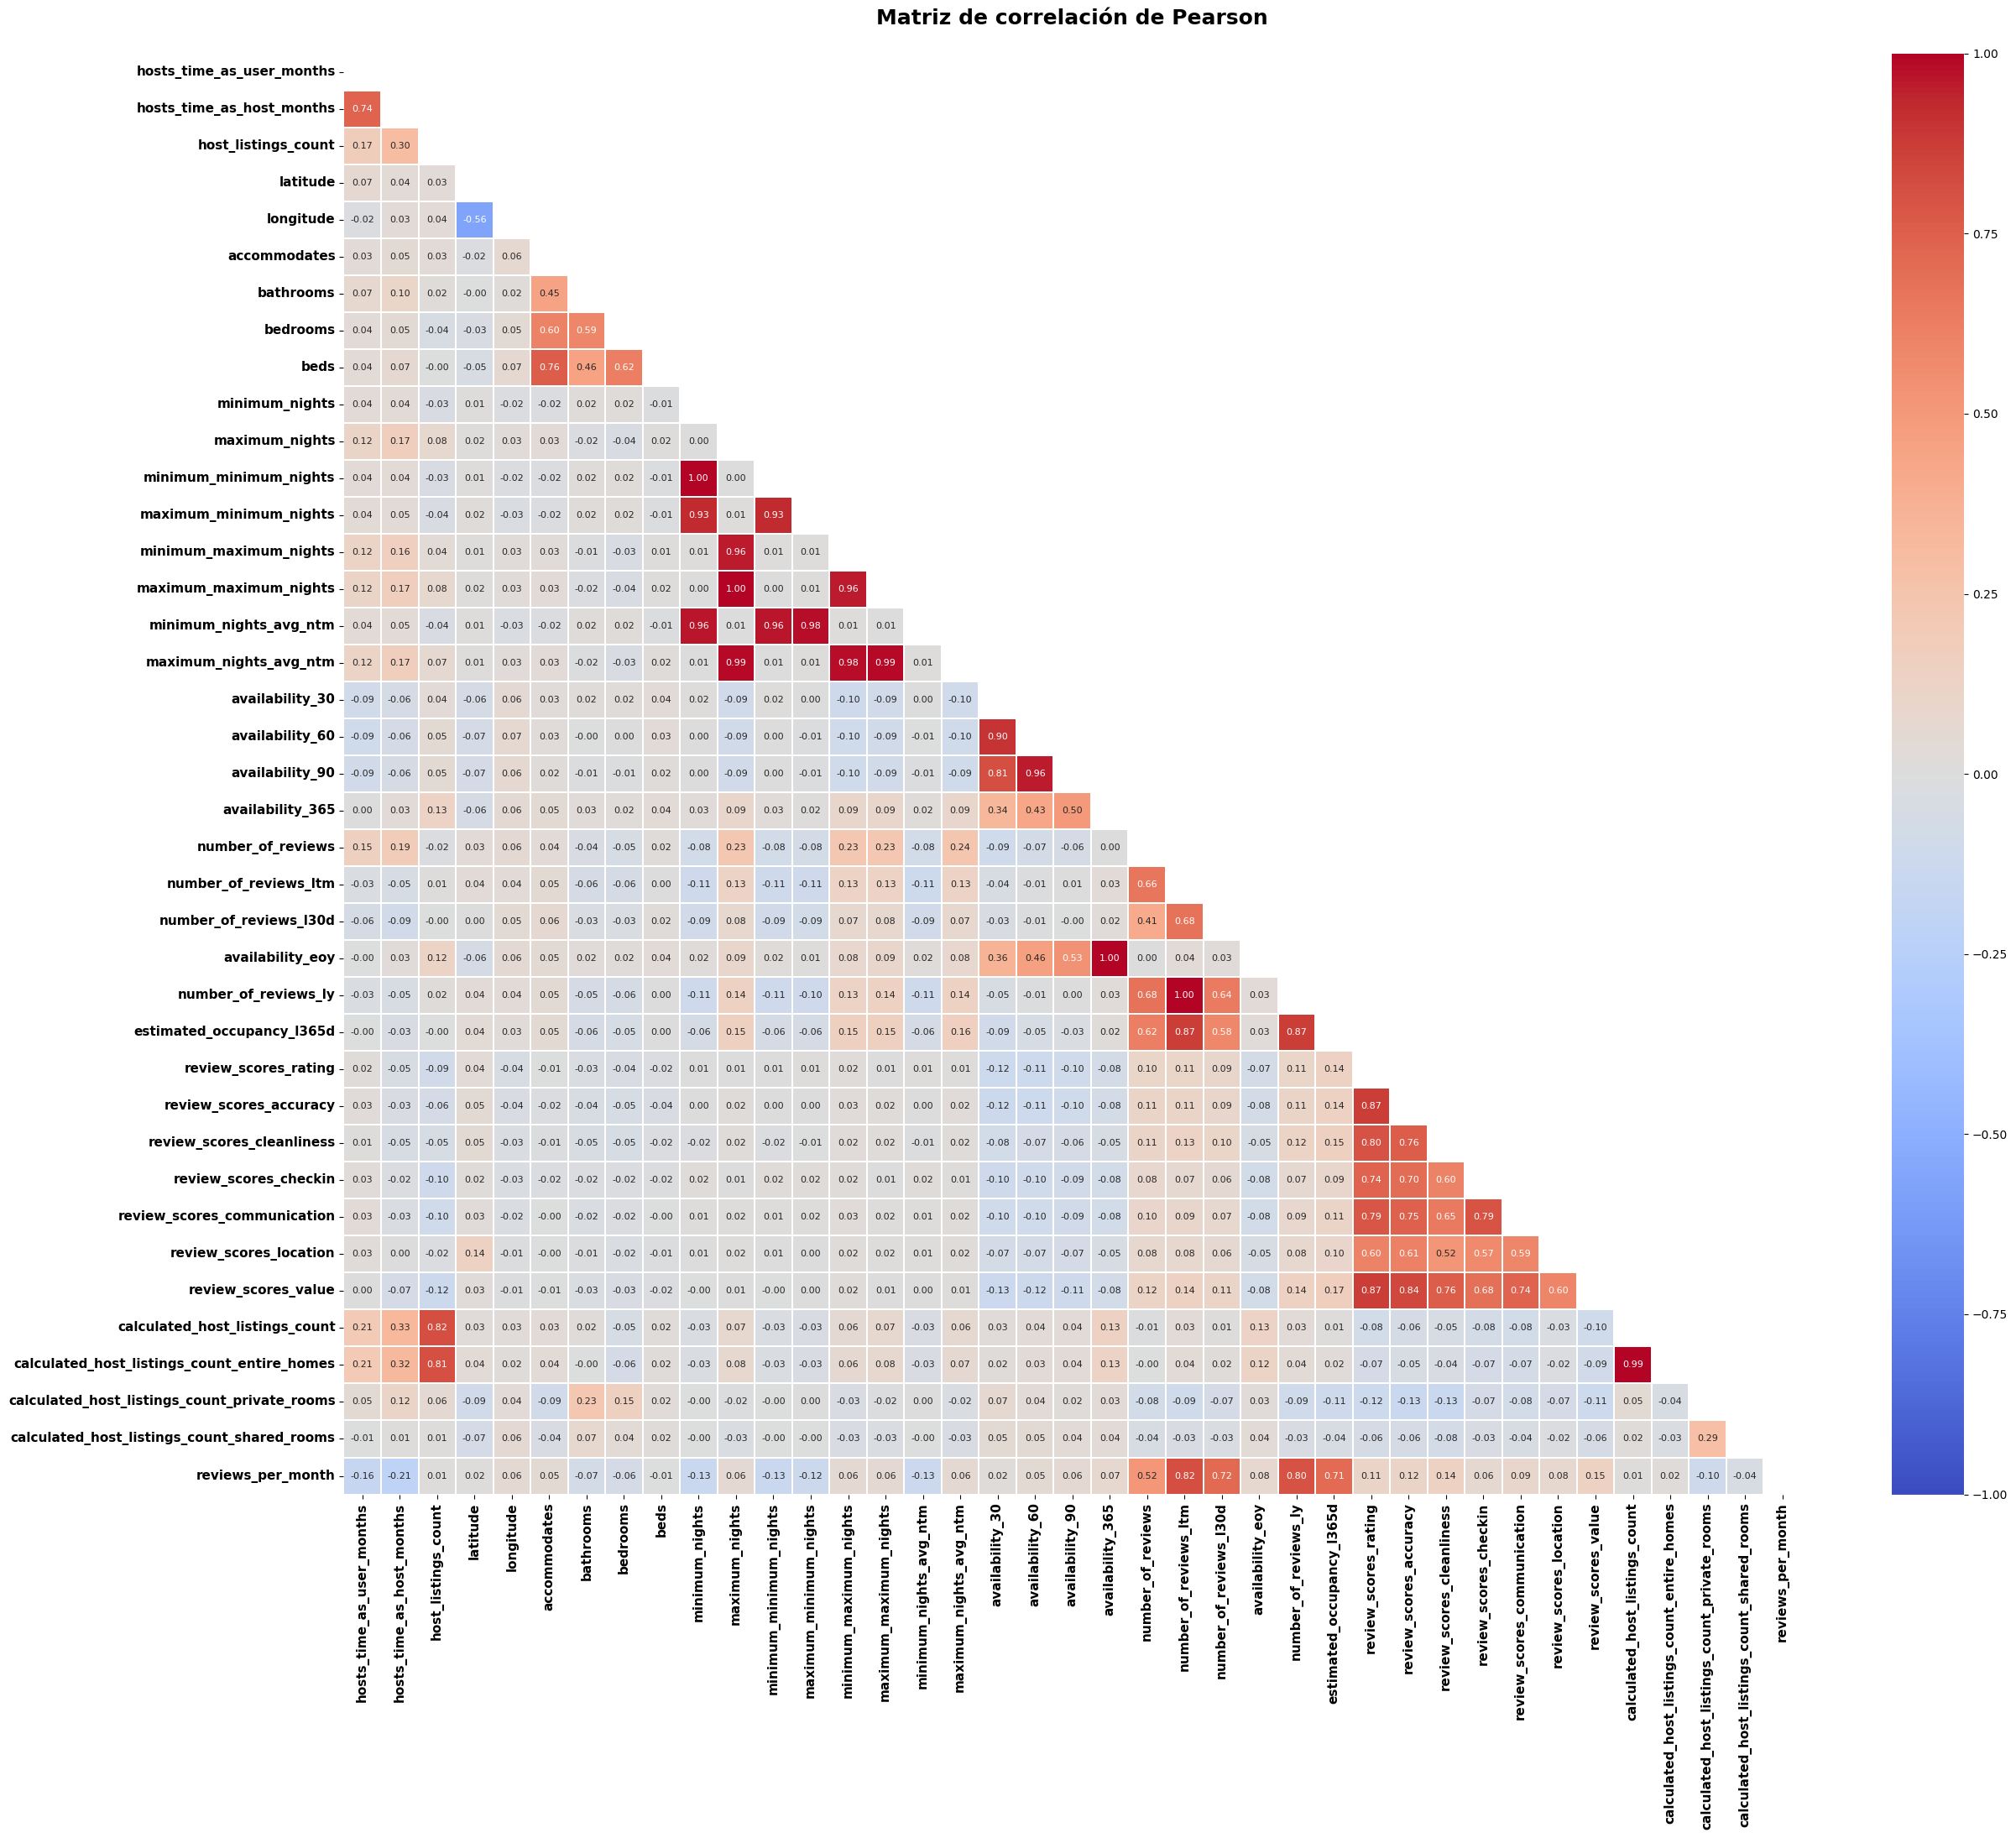

In [43]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="pearson")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Pearson",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

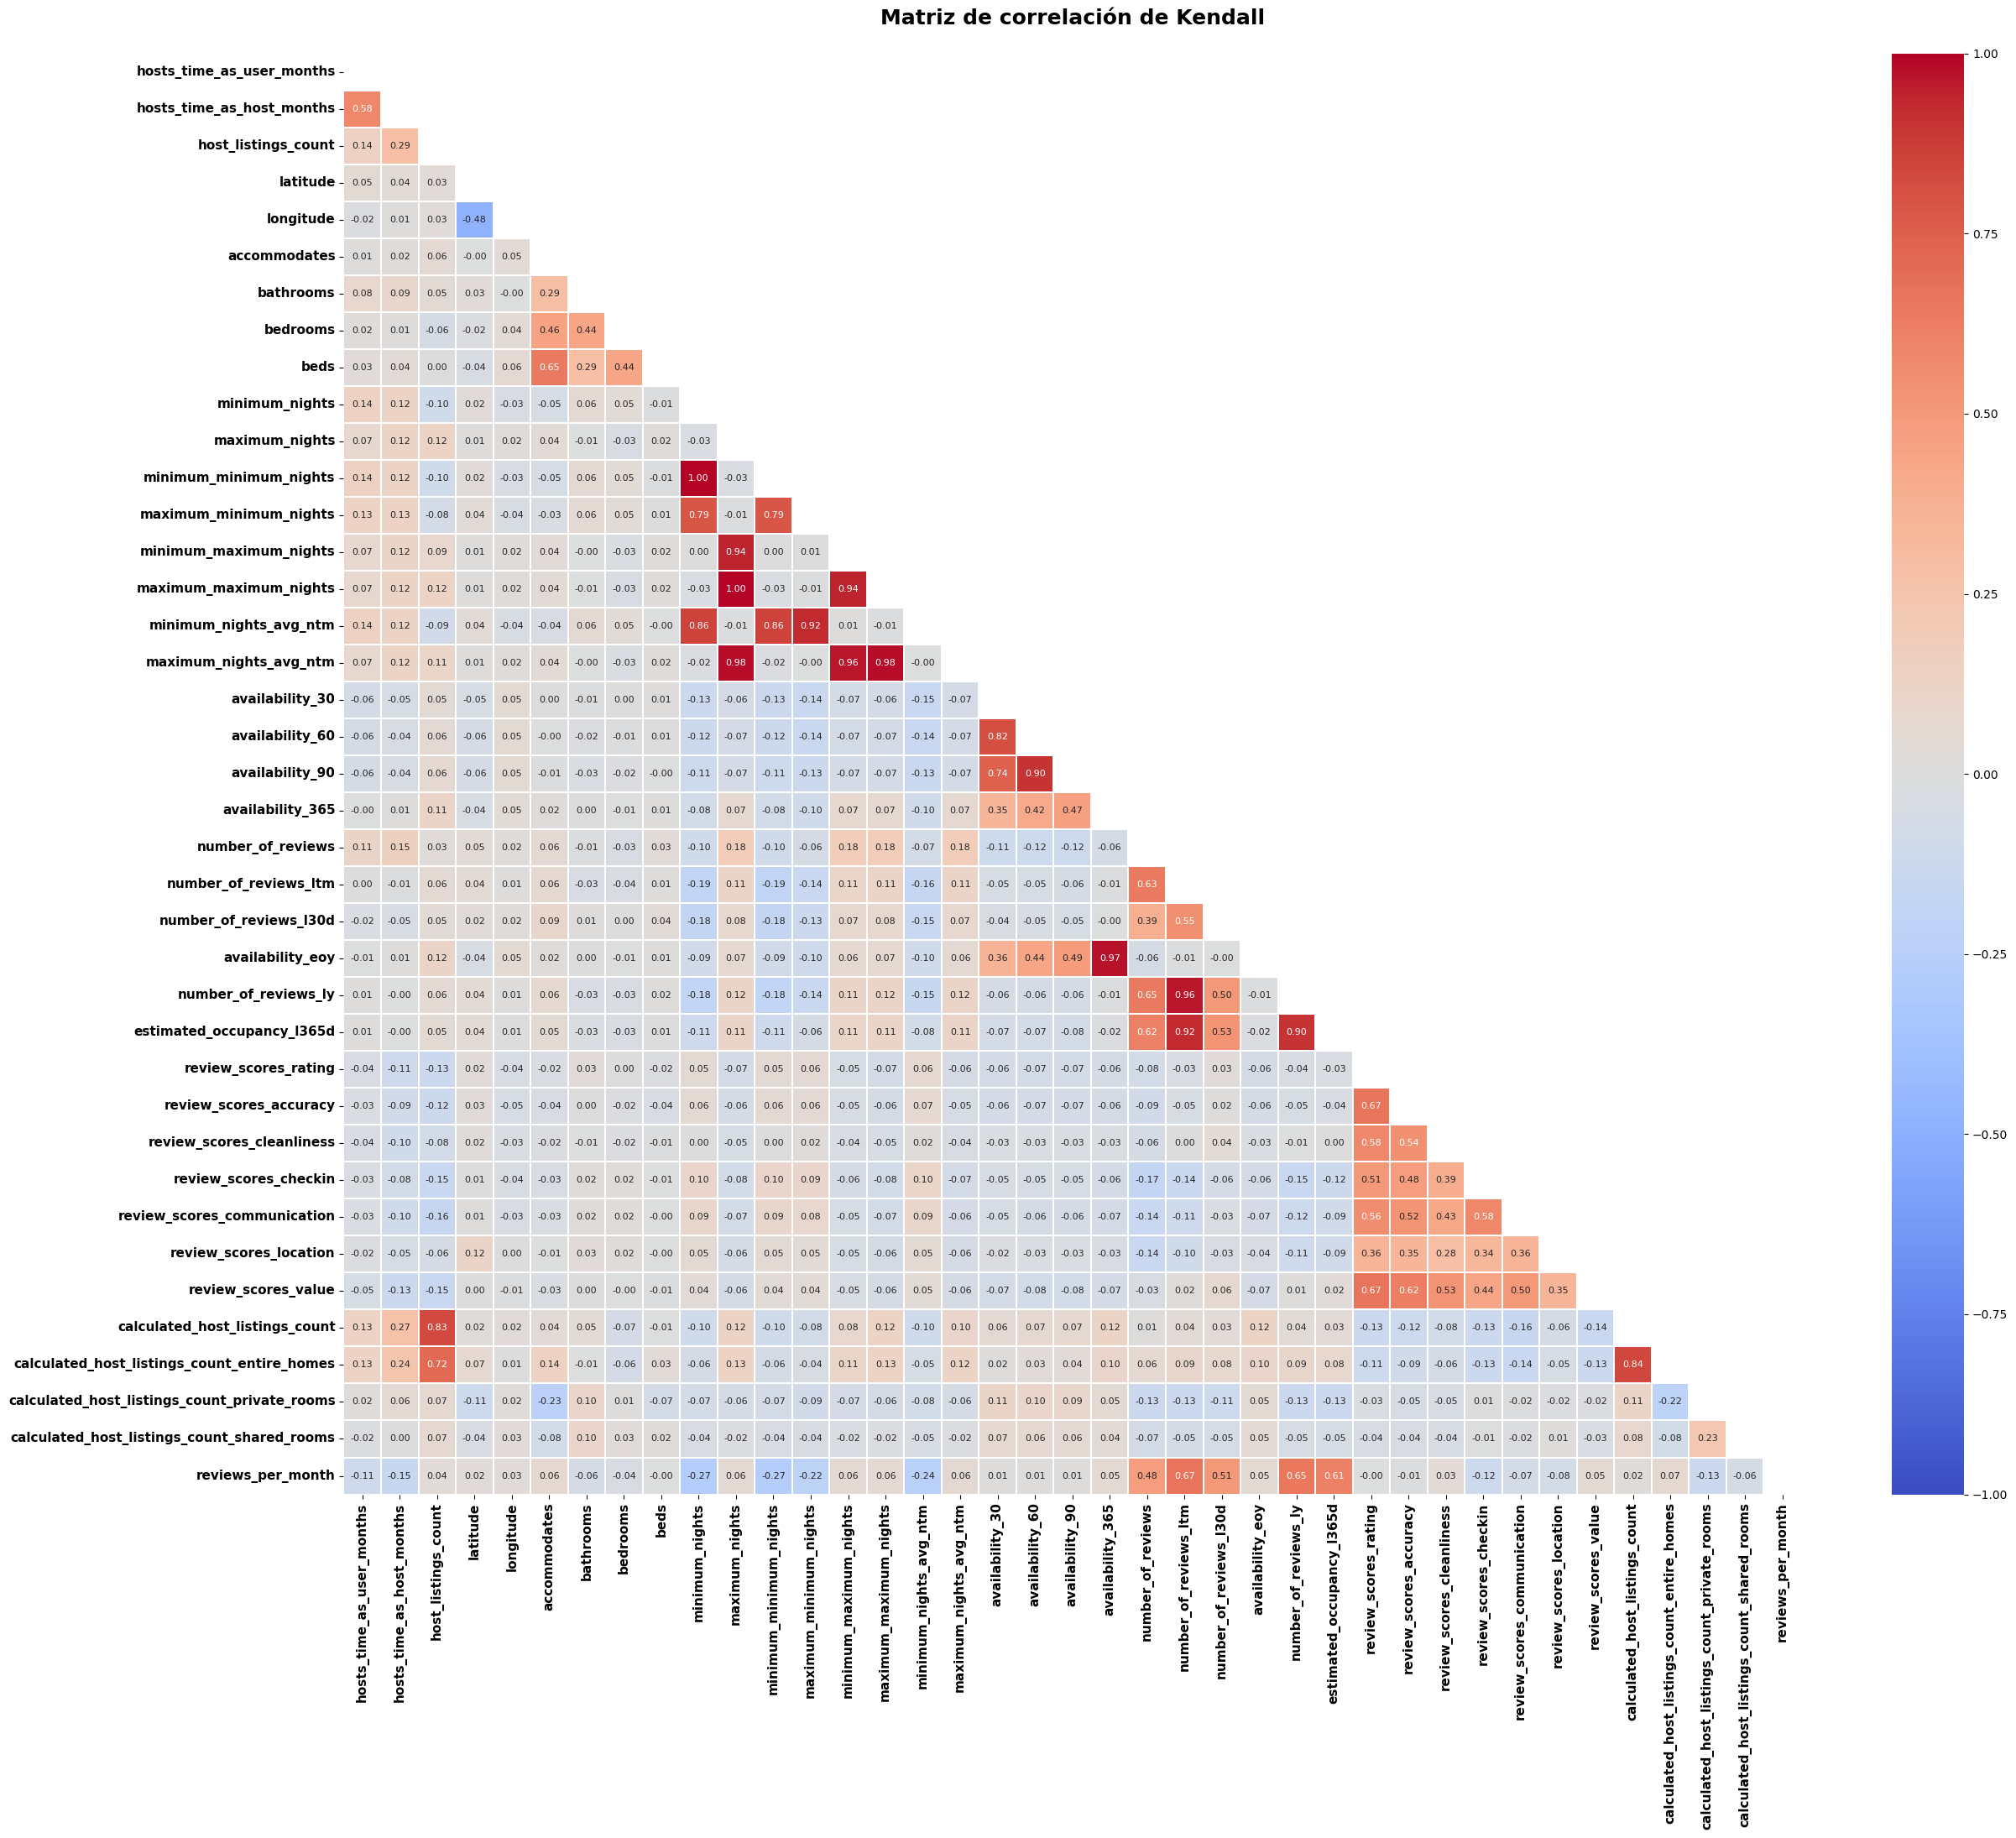

In [44]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="kendall")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Kendall",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

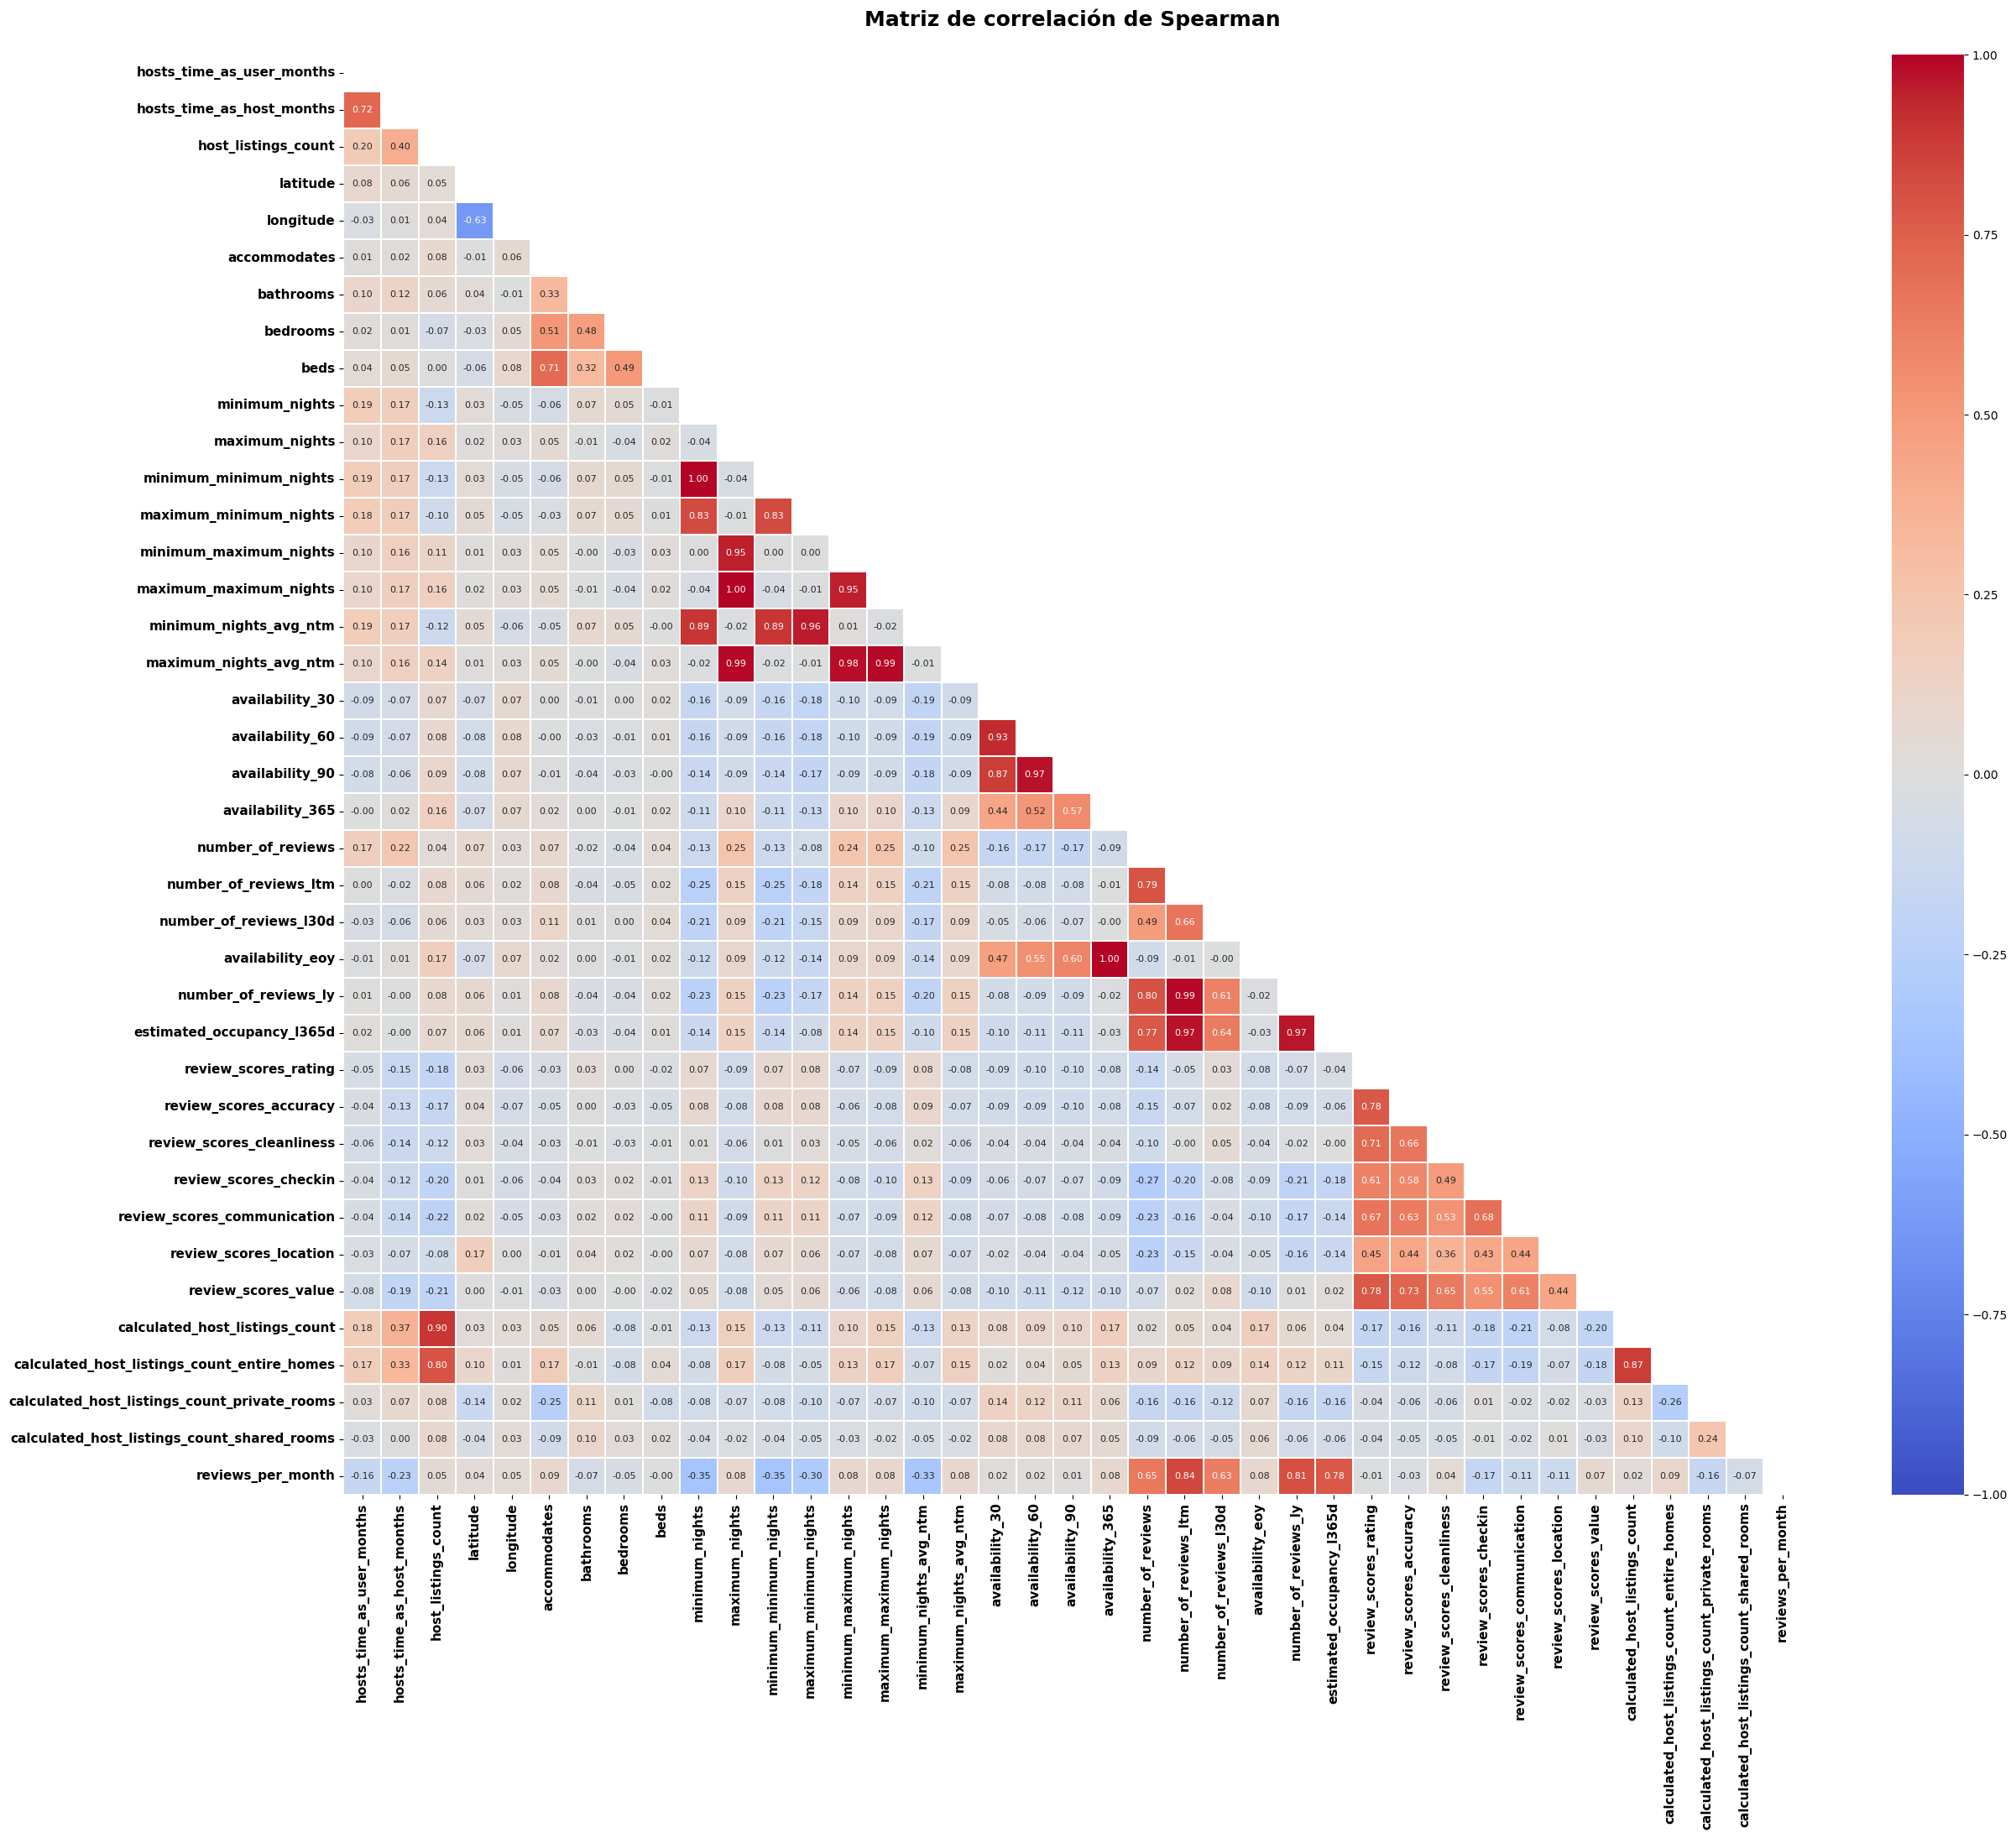

In [45]:
display(
    HTML(
        "<div style='max-height: 650px; max-width: 100%; overflow: auto; border: 2px solid #ccc; border-radius: 4px;'>"
    )
)

# Definimos un tamaño de lienzo interno para que los textos no se encimen
plt.figure(figsize=(26, 22))

# Calculamos la matriz de Pearson y ocultamos la mitad superior repetida
matriz_completa = df_numericas.corr(method="spearman")
mascara = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Dibujar el Heatmap
sns.heatmap(
    matriz_completa,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
    annot_kws={"size": 8},
    vmin=-1,
    vmax=1,
)

# Configuramos tipografias y titulos legibles
plt.xticks(rotation=90, fontsize=11, weight="bold")
plt.yticks(fontsize=11, weight="bold")
plt.title(
    "Matriz de correlación de Spearman",
    fontsize=18,
    weight="bold",
    pad=25,
)
plt.tight_layout()

# Renderizar el grafico dentro del contenedor y cerrar el bloque HTML
plt.show()
display(HTML("</div>"))

# Libera la memoria RAM inmediatamente para que la notebook no se vuelva lenta
plt.close()

### VARIABLES CATEGORICAS
* 35 categoricas nominales
* 4 categoricas ordinales

# NL hasta aca hice por ahora

<!-- Entonces eliminamos la variable property_type -->

In [ ]:
variables = ['bathrooms', 'beds']

for var in variables:
    ceros = (df3_3[var] == 0).sum()
    nulos = df3_3[var].isnull().sum()
    total = len(df3_3)
    print(f"{var}:")
    print(f"  == 0:   {ceros} registros ({ceros/total*100:.2f}%)")
    print(f"  NaN:    {nulos} registros ({nulos/total*100:.2f}%)")
    print()

In [ ]:
print(df3_3[df3_3['beds'] == 0]['room_type'].value_counts())

In [ ]:
df3_4 = df3_3[df3_3["bathrooms"].notna() & (df3_3["bathrooms"] != 0)]
df3_4 = df3_4[df3_4["beds"].notna() & (df3_4["beds"] != 0)]

df3_4.describe()

In [ ]:
df3_4.shape

4. **Analisis grafico de atributos**
Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [ ]:
df4_1 = df3_4
barrios_id_df = df4_1[["neighbourhood_cleansed", "id"]]
pd.options.display.min_rows = 20

Agrupamos por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [ ]:
barrios_id_df =  df4_1.groupby(['neighbourhood_cleansed'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [ ]:
top_barrios_df = df4_1[df4_1["neighbourhood_cleansed"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

Multiples graficos de frecuencia y derivados

In [ ]:
sns.countplot(x="neighbourhood_cleansed", data=top_barrios_df, hue="neighbourhood_cleansed", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood_cleansed', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
df4_1.describe()

Vamos a analizar la variable 'host_listings_count' que tiene un valor maximo de 562.

In [ ]:
p99 = df4_1['host_listings_count'].quantile(0.99)
datos = df4_1[df4_1['host_listings_count'] <= p99]['host_listings_count']

plt.figure(figsize=(10, 6))
sns.histplot(datos, bins=30, kde=True, color='skyblue')
plt.title('Distribución de host_listings_count (hasta p99)')
plt.xlabel('Cantidad de propiedades del anfitrión')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(df4_1['host_listings_count'].describe(percentiles=[.5, .75, .90, .95, .99]))

por lo que se observa hay un 1% de valores entre 183 y 562, son valores grandes pero no atipicos. Posiblemente sean empresas que manejan alojamientos y posiblemente tengan varios alojamientos superhost

In [ ]:
df4_1.describe()

Analizamos los barrios con mayor cantidad de reviews

In [ ]:
barrios_max = df4_1.groupby('neighbourhood_cleansed')["number_of_reviews_ltm"].count().sort_values(ascending=False).head(10)
top = barrios_max.reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=top, x='neighbourhood_cleansed', y='count', palette='pastel', 
            hue='neighbourhood_cleansed', legend=False, order=top['neighbourhood_cleansed'])
plt.title('Top 10 barrios por cantidad de reviews')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Verificamos que barrios tienen mas disponibilidad

In [ ]:
orden = df4_1.groupby('neighbourhood_cleansed')['availability_60'].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=df4_1[df4_1['neighbourhood_cleansed'].isin(orden)], x='availability_60', y='neighbourhood_cleansed', order=orden)

<!-- Nos quedamos con los top 5 barrios y creamos atributos categoricos binarios para cada uno -->

Grafico de disponibilidad

In [ ]:
sns.histplot(df4_2["availability_60"].dropna(), bins=40)
plt.title("Availability 60")
plt.xlabel("availability_60")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

In [ ]:
sns.scatterplot(data=df4_2, x='minimum_nights', y='number_of_reviews_ltm', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

In [ ]:
#plot_pie(Airbnb_df, "property_type")
top10 = df4_2["room_type"].value_counts().head(4).index
plot_prop_type = df4_2[df4_2["room_type"].isin(top10)]
colores = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    
]

labels = plot_prop_type["room_type"].value_counts().index
patches, texts = plt.pie(plot_prop_type["room_type"].value_counts(), colors=colores, startangle=90)
plt.title(f'Distribución de room_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
df4_2.describe()

Analizamos la distribucion de las variables

In [ ]:
variables = ['hosts_time_as_user_months', 'hosts_time_as_host_months', 
              'host_listings_count', 'accommodates', 'bathrooms', 'bedrooms', 
              'beds', 'minimum_nights', 'maximum_nights', 'availability_60', 
              'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_location']

print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(df4_2[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(7, 2, figsize=(14, 22))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = df4_2[var].quantile(0.99)
    datos = df4_2[df4_2[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último subplot vacío (13 variables en grilla de 14)
axes[-1].set_visible(False)

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

* Se analizan todas las variables y no hay nada atipico que reportar


Disponibilidad dependiendo del tipo de alojamiento

In [ ]:
plt.figure(figsize=(20, 4))
sns.boxplot(data=plot_prop_type, x='room_type', y='availability_60', 
            hue='room_type', legend=False, palette='pastel')
plt.tight_layout()
plt.show()

Vemos l;a distribucion de otras 3 variables

In [ ]:
sns.boxplot(x=df4_2["number_of_reviews"])
plt.title("Distribuicon de number_of_reviews")
plt.show()

In [ ]:
sns.boxplot(x=df4_2["host_listings_count"])
plt.title("Distribuicon de host_listings_count")
plt.show()

In [ ]:
sns.boxplot(x=df4_2["review_scores_rating"])
plt.title("Distribuicon de review_scores_rating")
plt.show()

Observamos una gran cantidad de outliers, pero esto se debe a la naturaleza del dataset y no un error en el dataset

Vemos si los hosts con mas propiedades tienen a tener mejor puntaje de reviews o si la experiencia les juega en contra

In [ ]:
variables = ['review_scores_rating', 'host_listings_count']
corr = df4_2[variables].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

* Vemos que la correlacion es debil y negativa lo cual indicaria que cuanto mas propiedades tiene un host, este tiend a dedicar menos tiempo a cada propiedad y eso lleva a obtener peores reviews
* Y que ocurre con la relacion entre los amenities y el puntaje? Estamos buscando correlacion entre un feature categorico binario y uno numerico -> punto biserial

In [ ]:
num_cols    = ['review_scores_rating', 'number_of_reviews_ltm']
binarias = ['coffee',	'wifi',	'parking',	'air_conditioning', 'pool', 'gym']

pb_mat = pd.DataFrame(index=num_cols, columns=binarias, dtype=float)

for num_col in num_cols:
    for bin_col in binarias:
        mask = df4_2[num_col].notna() & df4_2[bin_col].notna()
        num  = df4_2.loc[mask, num_col]
        bn   = df4_2.loc[mask, bin_col]
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = abs(r)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

* Solo hay una correlacion debil entre los puntajes y el atributo cafe, con lo cual seria bueno equipar los AirBnB con caferetas

## Pueden poner un pequenio resumen de EDA aca?

**Ya tenemos el dataset con los atributos relevantes y el target listo para su procesamiento y limpieza**

Primero estudiamos la distribucion del target

In [ ]:
counts = df4_2["host_is_superhost"].value_counts()

color_map = {
    1: "green",
    0: "red"
}

colors = [color_map[v] for v in counts.index]

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Superhosts")
plt.ylabel("")
plt.show()

Venos que es un problema de clasificacion balanceado

In [ ]:
df4_2.head()

In [ ]:
df4_2.shape

#### Vamos a realizar el train_test_split

In [ ]:
y = df4_2['host_is_superhost']
X = df4_2.drop(columns=['host_is_superhost']).copy()

Verificamos filas y columnas de X e y

In [ ]:
X.shape, y.shape

ahora vamos a realizar el train test split asi podemos realizar todas las traformaciones en el train y luego la aplicamos en el test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y )

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

## Reduccion de dimensionalidad

Ya quitamos algunas variables redundantes y sin datos y creamos otras que son utiles para el problema de ML (cambiar el atributo origical de bariro como string a variables binarias)

## Seleccion de atributos

Primero buscamos filtrar atributos redundantes (muy correlcionados entre si) o que puedan causar problemas de multicolinealidad

Ralizamos una matriz de correlacion entre las variables numericas para capturar posibles problemas de multicolinealidad en atributos. Suponemos que correlacion de Spearman (monotonica) mayor a 0.8 es indicativo de atributos redundantes

* Por otro lado prestamos atencion a la relacion entre los distintos puntajes de reviews entre ellos y la experiencia del host para darnos una idea de atributos de un host exitoso

In [ ]:
# Seleccionar solo las columnas numéricas de la lista
numerical_cols = X_train.select_dtypes(include=['number']).columns

# Calcular matriz de correlación Spearman
corr = X_train[numerical_cols].corr(method='spearman')

# Graficar
plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación - variables numéricas", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interesante que la experiencia del host como host y como usuario no esta para nada correlacionada con los puntajes de los reviews. Esto es una buena noticia porque como inversores solo podemos elegir en que invertir, pero no podemos comprar tiempo de experiencia
Resulta interesante tambien hecho de que la correlacion mas fuerte de ratings (el puntaje mas importante) es con 'accuracy' y 'value'. Esto se puede interpretar como que los usuarion valoran mucho la exactitud de la descripcion del listing y la relacion calidad-precio (value for money)

**Reducción de dimensionalidad por correlación entre variables numéricas**

A partir de la matriz de correlación de Spearman, identificamos tres grupos de 
variables altamente correlacionadas entre sí, lo que indica redundancia de información:

**Grupo 1 - Review scores**: `review_scores_rating`, `accuracy`, `cleanliness`, 
`checkin`, `communication` y `value` presentan correlaciones superiores a 0.55 entre sí. 
Conservamos `review_scores_rating` como representante del grupo (es la variable con 
correlaciones más altas y consistentes con el resto) y `review_scores_location`, 
que mantiene correlaciones bajas (~0.44) y por lo tanto aporta información distinta.

**Grupo 2 - Availability**: `availability_30`, `availability_90`, `availability_365` 
y `availability_eoy` presentan correlación moderada-alta con `availability_60` 
(mínimo 0.52). Conservamos únicamente `availability_60` como representante del grupo.

**Grupo 3 - Reviews/Occupancy**: `number_of_reviews`, `number_of_reviews_l30d`, 
`number_of_reviews_ly` y `estimated_occupancy_l365d` presentan correlación de al 
menos 0.66 con `number_of_reviews_ltm`. Conservamos `number_of_reviews_ltm` como 
representante del grupo.

Con esta reducción pasamos de 13 variables potencialmente redundantes a 4, 
disminuyendo la dimensionalidad sin perder información relevante para el análisis.

## Yo aca quitaria id y host_id porque solo agregan ruido

In [ ]:
columnas_eliminar = [
    # Grupo 1 - Review scores
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_value',
    
    # Grupo 2 - Availability
    'availability_30',
    'availability_90',
    'availability_365',
    'availability_eoy',
    
    # Grupo 3 - Reviews/Occupancy
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
]

X_train = X_train.drop(columns=columnas_eliminar).copy()
X_test = X_test.drop(columns=columnas_eliminar).copy()
print(X_train.shape)
print(X_train.columns.tolist())

In [ ]:
X_train.describe()

Vamos a analizar la relacon entre las varibles 'room_type' y 'property_type'.  Como vemos room_type es una agrupamiento de las caracteristicas de property_type. Por lo tanto vamos a eliminar la columna property_type

In [ ]:
X_train[['room_type', 'property_type']].value_counts()

Hacemos una verifiacion por CremmerV  para ver si mantiene realcion con el target

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

v_room = cramers_v(X_train['room_type'], y_train)
print(f"Cramér's V room_type vs target: {v_room:.4f}")

Entonces eliminamos la variable property_type

In [ ]:
X_train = X_train.drop(columns=['property_type']).copy()
X_test = X_test.drop(columns=['property_type']).copy()

#### Ahora vamos a trabajar con  de las variables categoricas

In [ ]:
X_train.describe(include='str')

Vamos a analizar la variable 'has_availavility' 

In [ ]:
X_train['has_availability'].value_counts()

'has_avalibility' es una variable constnate todo los valores son True por lo tanto no aporta valor y la vamos a eliminar

In [ ]:
X_train=X_train.drop(columns=['has_availability']).copy()
X_test=X_test.drop(columns=['has_availability']).copy()

Luego seguimos con host_identitiy_verified                      

In [ ]:
X_train['host_identity_verified'].value_counts()

Tiene varios valores esta variable y parece bastante util, ya que tener la identidad verificada deberia generar confianza en los huespedes.
Entonces vamos a hacer 't'=1 y 'f'= 0

In [ ]:
X_train['host_identity_verified'] = X_train['host_identity_verified'].map({'t': 1, 'f': 0})
X_test['host_identity_verified'] = X_test['host_identity_verified'].map({'t': 1, 'f': 0})

Ahora avanzamos con la variable 'neighbourhood_cleansed'. vemos que esta variable cuenta con 48 datos distintos, lo que vamos hacer es agruparlos por columnas por lo que nos deberia quedar de solo 14 variables y ahi podemos hacer un OHE

Importo un csv con las comunas

In [ ]:
comunas = pd.read_csv(r'barrios_comunas_caba.csv')

Verificamos que los barrios coincidan

In [ ]:
barrios_no_match = set(X_train['neighbourhood_cleansed'].unique()) - set(comunas['barrio'].unique())
print(f"Barrios sin match: {barrios_no_match}")

In [ ]:
X_train = X_train.merge(comunas, left_on='neighbourhood_cleansed', right_on='barrio', how='left')
X_train = X_train.drop(columns=['neighbourhood_cleansed', 'barrio']).copy()

# Verificar que no quedaron nulos en comuna
print(X_train['comuna'].isnull().sum())
print(X_train.shape)

In [ ]:
X_test = X_test.merge(comunas, left_on='neighbourhood_cleansed', right_on='barrio', how='left')
X_test = X_test.drop(columns=['neighbourhood_cleansed', 'barrio']).copy()

Verificamos que nos queda la variable comuna con 15 variables

In [ ]:
X_train['comuna'].unique()

Vamos  realizar el OHE a la variable 'comuna' y a la variable 'roon_type' ya que vemos que cuenta con solo 4 variables

In [ ]:
X_train

## JPC: Este codigo no me funciona:
 "None of [Index(['comuna', 'room_type'], dtype='str')] are in the [columns]"

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Definir columnas a codificar
columnas_ohe = ['comuna', 'room_type']

# Instanciar el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit y transform en X_train
ohe_train = ohe.fit_transform(X_train[columnas_ohe])

# Crear dataframe con las nuevas columnas
ohe_cols = ohe.get_feature_names_out(columnas_ohe)
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)

# Eliminar columnas originales y agregar las codificadas
X_train = X_train.drop(columns=columnas_ohe)
X_train = pd.concat([X_train, ohe_train_df], axis=1)

X_test = X_test.drop(columns=columnas_ohe)
X_test = pd.concat([X_train, ohe_train_df], axis=1)


In [ ]:
X_train.head()

Varificamos con ya no quedan variables categoricas, y se agregaron al final las columnas del OHE.

## JPC: Esto deberia ser parte del EDA antes del split, no?

#### Vamos a verificar los valor nulos que existan

In [ ]:
X_train.isnull().sum().sort_values(ascending=False)

Vemos que los valores faltante de review_scores_rating y review_scores_location tienen la misma cantidad y vimos cuando hicimos los anlisis de variable es porque tienen o reviews.

In [ ]:
# Verificar que los nulos en review_scores coinciden con 0 reviews
print(X_train[X_train['review_scores_rating'].isnull()]['number_of_reviews_ltm'].describe())

# Ver cuántos tienen 0 reviews en total
print(f"\nTotal con number_of_reviews_ltm == 0: {(X_train['number_of_reviews_ltm'] == 0).sum()}")
print(f"Total con review_scores_rating nulo: {X_train['review_scores_rating'].isnull().sum()}")

Es decir: 100% de los nulos en review_scores corresponden a alojamientos sin reseñas recientes, confirma que el faltante es MAR (Missing At Random, condicionado a otra variable observada: no tener reviews)

Vamos la distribucion de las variables

In [ ]:
variables = ['review_scores_rating', 'review_scores_location']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    sns.histplot(X_train[var].dropna(), bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    # Líneas de media y mediana
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de review scores (sin nulos)', fontsize=14)
plt.tight_layout()
plt.show()

Ambas variables presentan asimetría negativa (cola hacia la izquierda). En distribuciones asimétricas, la media se ve afectada por los valores extremos, 
desplazándose hacia ellos. La mediana, al ser el valor central, representa mejor el comportamiento típico y es más robusta ante estos outliers. Por lo tanto, optamos por imputar con la mediana.

Vamos a analizar las variables 'minimum_nights', 'maximum_nights' que tienen la misma cantida de ausentes

In [ ]:
variables = ['minimum_nights', 'maximum_nights']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de minimum_nights y maximum_nights', fontsize=14)
plt.tight_layout()
plt.show()

Vemos comportamientos distintos de la distribucion. En 'minimum_nights' se ve una distribucion asimetrica con cola hacia la derecha entonces para imputar con el menor impacto en la distribucion lo hacemos con la mediana que vemos cae donde esta la mayor poblacion. 
En el caso del 'maximum_nights' es una distgribucion multimodal con varios picos, asi que si imputamos la mediana vemos que cae en el pico mas pronunciado que es 365 que debe ser el valor mas estandar que se pone por defecto.
Conclusion en ambos graficos hay que imputar con la mediana.

Ahora analicemos la ultima que nos falta que seria bedrooms

In [ ]:
p99 = X_train['bedrooms'].quantile(0.99)
datos = X_train[X_train['bedrooms'] <= p99]['bedrooms'].dropna()

plt.figure(figsize=(8, 5))
sns.histplot(datos, bins=20, kde=True, color='skyblue')

media = X_train['bedrooms'].mean()
mediana = X_train['bedrooms'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.legend()

plt.title('Distribución de bedrooms (hasta p99)')
plt.xlabel('bedrooms')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Mismo patro y conclusiones tomadas para maximum_night. PAtron multimodal y vamos a imputar por la mediana que es quien menos nos altera la destribucion de la variable.

Concluimos que todas las variables se imputan por la mediana

In [ ]:
from sklearn.impute import SimpleImputer

columnas_imputar = ['review_scores_rating', 'review_scores_location', 
                     'minimum_nights', 'maximum_nights', 'bedrooms']

imputer = SimpleImputer(strategy='median')

X_train[columnas_imputar] = imputer.fit_transform(X_train[columnas_imputar])

print(X_train[columnas_imputar].isnull().sum())

Por ultimo corroboramos que no hay mas valores ausentes.

#### Analicemos si existen outliers

In [ ]:
X_train.describe()

Vamos analizar alguna variables que pueden taner valores maximas mas llamativos

In [ ]:
variables = ['host_listings_count', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews_ltm']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(X_train[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

Se observa en todas las variables que pueden tener algunos valores altos pero no son atipicos sino de huespedes especiales.
CONCLUSION NO SE ANULA NINGUN DATO POR OUTLIERS

In [ ]:
X_train.head()

Aunque Phi y point-biserial provienen de tradiciones estadísticas distintas (Chi-cuadrado para tablas de contingencia vs. correlación de Pearson), ambas 
se reducen matemáticamente a la misma fórmula cuando las dos variables son binarias (0/1) — Phi es simplemente Pearson aplicado a ese caso particular. 
Por eso usamos una sola función para calcular la asociación de todas las features (numéricas y binarias) contra el target.

In [ ]:
from scipy import stats

def asociacion_con_target(X, y, col):
    valores_unicos = X[col].nunique()
    
    if valores_unicos < 2:
        return {'feature': col, 'tipo': 'constante', 'asociacion': np.nan, 'p_value': np.nan}
    
    try:
        corr, pvalue = stats.pointbiserialr(y, X[col])
    except Exception as e:
        return {'feature': col, 'tipo': 'error', 'asociacion': np.nan, 'p_value': np.nan}
    
    tipo = "Phi (binaria)" if valores_unicos == 2 else "Point-biserial (numerica)"
    
    return {'feature': col, 'tipo': tipo, 'asociacion': corr, 'p_value': pvalue}


resultados = []
for col in X_train.columns:
    if col in ['id', 'host_id']:
        continue
    resultados.append(asociacion_con_target(X_train, y_train, col))

resultados_df = pd.DataFrame(resultados)
resultados_df['asociacion_abs'] = resultados_df['asociacion'].abs()
resultados_df = resultados_df.sort_values('asociacion_abs', ascending=False)


def interpretar_asociacion(row):
    valor = row['asociacion']
    pvalue = row['p_value']
    
    if pd.isna(valor):
        return "no calculable"
    
    if pvalue >= 0.05:
        return "no significativa"
    
    v = abs(valor)
    if v < 0.1:
        return "significativa - débil"
    elif v < 0.3:
        return "significativa - débil-moderada"
    elif v < 0.5:
        return "significativa - moderada-fuerte"
    else:
        return "significativa - fuerte"

resultados_df['interpretacion'] = resultados_df.apply(interpretar_asociacion, axis=1)
print(resultados_df.to_string(index=False))

## JPC: La significancia estadistica tiene como requisito que los datos tengan __distribucion normal y que la varianza sea homogenea__, creo que punto biserial funcionan siempre. __Mutual Information__ tambien deberia funcionar

Para la selección de features, utilizamos como criterio la **significancia estadística** (p-value < 0.05) de la asociación entre cada feature y el target 
`host_is_superhost`, calculada mediante point-biserial/Phi según corresponda.
A diferencia de filtrar por la magnitud del coeficiente (que descartaría prácticamente todas las variables al ser, en su mayoría, asociaciones débiles), 
este criterio responde a la pregunta de si la asociación observada es estadísticamente distinguible del azar, independientemente de su tamaño

In [ ]:
# Filtrar features con asociación estadísticamente significativa (p < 0.05)
seleccionadas = resultados_df[resultados_df['p_value'] < 0.05]['feature'].tolist()
descartadas = resultados_df[resultados_df['p_value'] >= 0.05]['feature'].tolist()

print(f"Variables seleccionadas: {len(seleccionadas)}")
print(seleccionadas)
print(f"\nVariables descartadas (p >= 0.05): {len(descartadas)}")
print(descartadas)

## Hay que aplicar todas las transformaciones y remocion de features a x_test tb?

In [ ]:
# Aplicar el filtro a X_train
X_train = X_train[seleccionadas].copy()
print(X_train.shape)

In [ ]:
X_train.head()

#### En el siguiente paso vamos a escalar  los valores

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [ ]:
X_train_scaled.head()

##### La variable target `host_is_superhost` presenta una distribución de 57.7% (0) y 42.3% (1), lo cual representa un dataset prácticamente balanceado. Por lo tanto, 
##### no es necesario aplicar técnicas de balanceo (SMOTE, undersampling, etc.). Adicionalmente, se utilizó `stratify=y` en el train/test split para preservar 
##### esta proporción tanto en el conjunto de entrenamiento como en el de test.

Avanzamos con la reduccion de dimencionalidad PCA

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA sobre los datos escalados
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, color='skyblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', color='teal')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Cantidad de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Componentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")
print(f"Componentes para 95% varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")

El análisis de PCA muestra que la varianza está distribuida de forma relativamente uniforme entre las componentes principales, requiriendo 
27-28 de las 30 componentes originales para retener el 95% de la varianza. Esto indica baja redundancia entre las variables tras la selección de features 
previamente realizada, por lo que PCA no resulta una técnica efectiva para reducir significativamente la dimensionalidad en este caso sin una pérdida 
considerable de información.

#### Ahora vamos a realizar la transfomaciones del X_test

Primero vamos a eliminar la variable 'has_availability'

In [ ]:
X_test = X_test.drop(columns=['has_availability']).copy()

La siguiente variable host_identity_verified que vamos a codificar con 0 y 1 es

In [ ]:
X_test['host_identity_verified'] = X_test['host_identity_verified'].map({'t': 1, 'f': 0})

Vamos a hacer el merge entre X_test y el csv de comunas

In [ ]:
X_test = X_test.merge(comunas, left_on='neighbourhood_cleansed', right_on='barrio', how='left')
X_test = X_test.drop(columns=['neighbourhood_cleansed', 'barrio']).copy()

Ahora vamos a realizar el OHE de las variables comuna y room_type

In [ ]:
ohe_test = ohe.transform(X_test[['comuna', 'room_type']])
ohe_cols = ohe.get_feature_names_out(['comuna', 'room_type'])
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)

X_test = X_test.drop(columns=['comuna', 'room_type'])
X_test = pd.concat([X_test, ohe_test_df], axis=1)

Ahora vamos a imputar los nulos con el simple imputer ya fiteado

In [ ]:
columnas_imputar = ['review_scores_rating', 'review_scores_location', 
                     'minimum_nights', 'maximum_nights', 'bedrooms']
X_test[columnas_imputar] = imputer.transform(X_test[columnas_imputar])

Aplicamos el mismo filtro de P value que utilizamos en el X_train

In [ ]:
X_test = X_test[seleccionadas].copy()

Y por ultimo hacemos el escalamiento

In [ ]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
X_test_scaled.shape

In [ ]:
X_test_scaled.head()

Dado que el análisis de PCA sobre `X_train` mostró que la varianza está distribuida de forma relativamente uniforme entre las componentes (requiriendo 
~27-28 de 30 componentes para retener el 95% de la varianza), se decidió **no aplicar PCA** como técnica de reducción de dimensionalidad. Esta decisión 
se mantiene de forma consistente para `X_test`, que conserva las mismas features seleccionadas que `X_train`.